In [1]:
import pandas as pd
import json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import AdamW
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from tqdm import tqdm
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

In [2]:
data_dir = Path('/home/andrze06/projects/Spectras-latent-space/data/multimodal_spectroscopic_dataset')
files = sorted(data_dir.glob("aligned_chunk_*.parquet"))
dfs = [pd.read_parquet(f, columns=['smiles', 'c_nmr_spectra']) for f in files]
df = pd.concat(dfs, ignore_index=True)

In [3]:
df.head()

,smiles,c_nmr_spectra
0,COc1nc2ccccc2cc1C(=O)O,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,CCOC(=O)c1cc2c(OCc3coc4cc(F)ccc34)cccc2n1C(=O)...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,CCCCOc1c(CN2C(=O)c3ccccc3C2=O)n(CC2CC2)c(=O)c2...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,CCCCNC[C@@H]1O[C@](O)(CO)[C@@H](O)[C@@H]1O,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,O=C(NCC1CC1)c1nc2c(N3CCC(n4c(=O)[nH]c5ccccc54)...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [106]:
scale = 1e4

def transform_data(targets_list):
    return [np.log1p(t * scale).astype(np.float32) for t in tqdm(targets_list)]

def inverse_transform_data(y):
    return np.expm1(y) / scale

data = np.array(df['c_nmr_spectra'].to_list(), dtype=np.float32)
data = np.array(transform_data(data))

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 794386/794386 [00:10<00:00, 72486.00it/s]


In [166]:
len(coeffs)

6

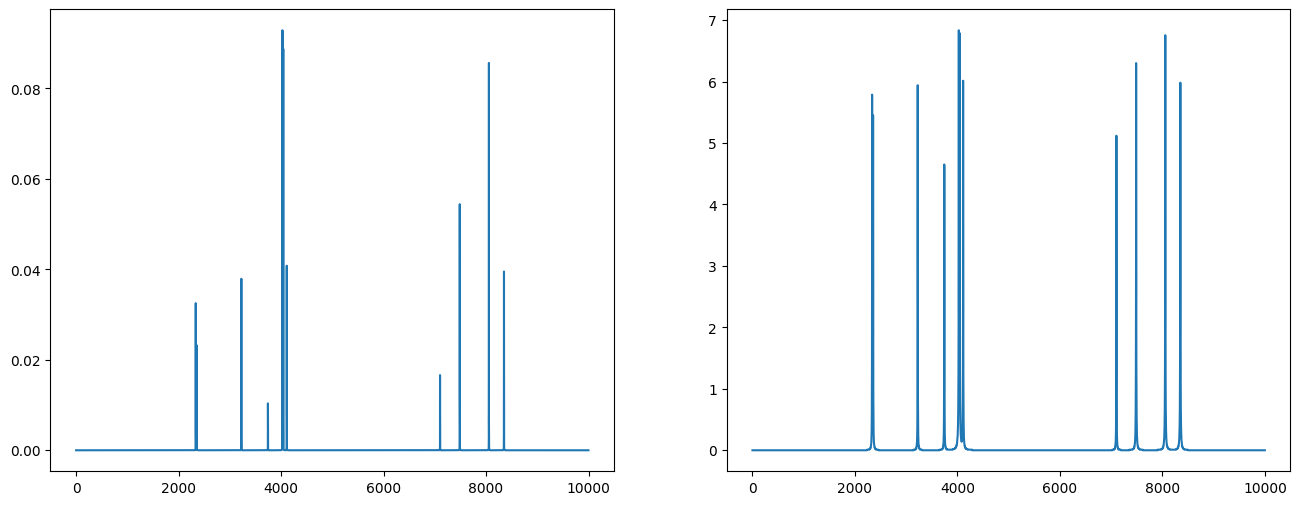

2034


In [108]:
idx = np.random.randint(len(data))
sample = data[idx]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(inverse_transform_data(sample))
axes[1].plot(sample)
plt.show()
print((sample != 0).sum())

In [109]:
    # split and normalize data
    train_data, dummy = train_test_split(data, test_size=0.2, random_state=42)
    val_data, test_data = train_test_split(dummy, test_size=0.5, random_state=42)
    print(train_data.shape, val_data.shape, test_data.shape)

    # std = train_data.std(axis=0)
    # train_data /= std
    # val_data /= std

(635508, 10000) (79439, 10000) (79439, 10000)


In [ ]:
class MLPVAE(nn.Module):
    def __init__(self, input_dim, latent_dim, dropout=0.1):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.LayerNorm(1024),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.LayerNorm(512),
        )
        self.fc_mu = nn.Linear(512, latent_dim)
        self.fc_logvar = nn.Linear(512, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.LayerNorm(512),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.LayerNorm(1024),
            nn.Linear(1024, input_dim)
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        if self.training:
            std  = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        else:
            return mu
        
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_out = F.softplus(self.decode(z))
        return x_out, mu, logvar
    
def vae_loss(preds, targets, mu, logvar, beta=0.1):
    rec = F.l1_loss(preds, targets)
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return rec + beta * kl, rec, kl

In [148]:
device = 'cuda'
input_dim = data[0].shape[0]
latent_dim = 256
batch_size = 512
lr = 3e-4

model = MLPVAE(input_dim, latent_dim).to(device)
optimizer = AdamW(model.parameters(), lr=lr)

train_loader = DataLoader(train_data, batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size, shuffle=False)

epochs = 1000
beta = 0.01

for epoch in range(epochs):
    train_loss = 0
    val_loss = 0
    rec_loss = 0
    kl_loss = 0

    #pbar = tqdm(train_loader)
    for x in train_loader:
        x = x.to(device)
        x_pred, mu, logvar = model(x)
        loss, rec, kl = vae_loss(x_pred, x, mu, logvar, beta)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        #pbar.set_postfix({"rec": f"{rec.item():.3f}", "kl": f"{kl.item():.3f}",  "tot": f"{loss.item():.3f}"})        
        train_loss += loss.item()
        rec_loss += rec.item()
        kl_loss += kl.item()

    model.eval()
    with torch.no_grad():
        for x in val_loader:
            x = x.to(device)
            x_pred, mu, logvar = model(x)
            loss, rec, kl = vae_loss(x_pred, x, mu, logvar, beta)
            val_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)
    rec_loss /= len(train_loader)
    kl_loss /= len(train_loader)
    print(f"Epoch: {epoch:03d} | total={train_loss:.4f} | rec={rec_loss:.4f} | kl={kl_loss:.4f} | val={val_loss:.4f}")

Epoch: 000 | total=0.0671 | rec=0.0664 | kl=0.0743 | val=0.0628
Epoch: 001 | total=0.0559 | rec=0.0558 | kl=0.0075 | val=0.0495
Epoch: 002 | total=0.0461 | rec=0.0461 | kl=0.0064 | val=0.0443
Epoch: 003 | total=0.0424 | rec=0.0424 | kl=0.0053 | val=0.0414
Epoch: 004 | total=0.0401 | rec=0.0400 | kl=0.0048 | val=0.0391
Epoch: 005 | total=0.0380 | rec=0.0380 | kl=0.0045 | val=0.0375
Epoch: 006 | total=0.0363 | rec=0.0363 | kl=0.0043 | val=0.0359
Epoch: 007 | total=0.0351 | rec=0.0350 | kl=0.0041 | val=0.0350
Epoch: 008 | total=0.0342 | rec=0.0342 | kl=0.0040 | val=0.0340
Epoch: 009 | total=0.0334 | rec=0.0334 | kl=0.0038 | val=0.0334
Epoch: 010 | total=0.0328 | rec=0.0328 | kl=0.0036 | val=0.0327
Epoch: 011 | total=0.0323 | rec=0.0323 | kl=0.0035 | val=0.0324
Epoch: 012 | total=0.0319 | rec=0.0319 | kl=0.0034 | val=0.0322
Epoch: 013 | total=0.0316 | rec=0.0316 | kl=0.0033 | val=0.0319
Epoch: 014 | total=0.0314 | rec=0.0314 | kl=0.0032 | val=0.0317
Epoch: 015 | total=0.0312 | rec=0.0311 |

KeyboardInterrupt: 

In [149]:
# R2 and visualisation
def get_preds_targets_latents(model, loader, limit=50):
    model.eval()
    preds = []
    targets = []
    latents = []
    i = 0
    with torch.no_grad():
        for x in loader:
            x_pred, mu, logvar = model(x.to(device))
            preds.append(x_pred.cpu().numpy())
            targets.append(x.cpu().numpy())
            latents.append(mu.cpu().numpy())
            i+=1
            if i > limit:
                break
    return np.concatenate(preds, axis=0), np.concatenate(targets, axis=0), np.concatenate(latents, axis=0)

preds_train, targets_train, zs_train = get_preds_targets_latents(model, train_loader)
preds_val, targets_val, zs_val = get_preds_targets_latents(model, val_loader)

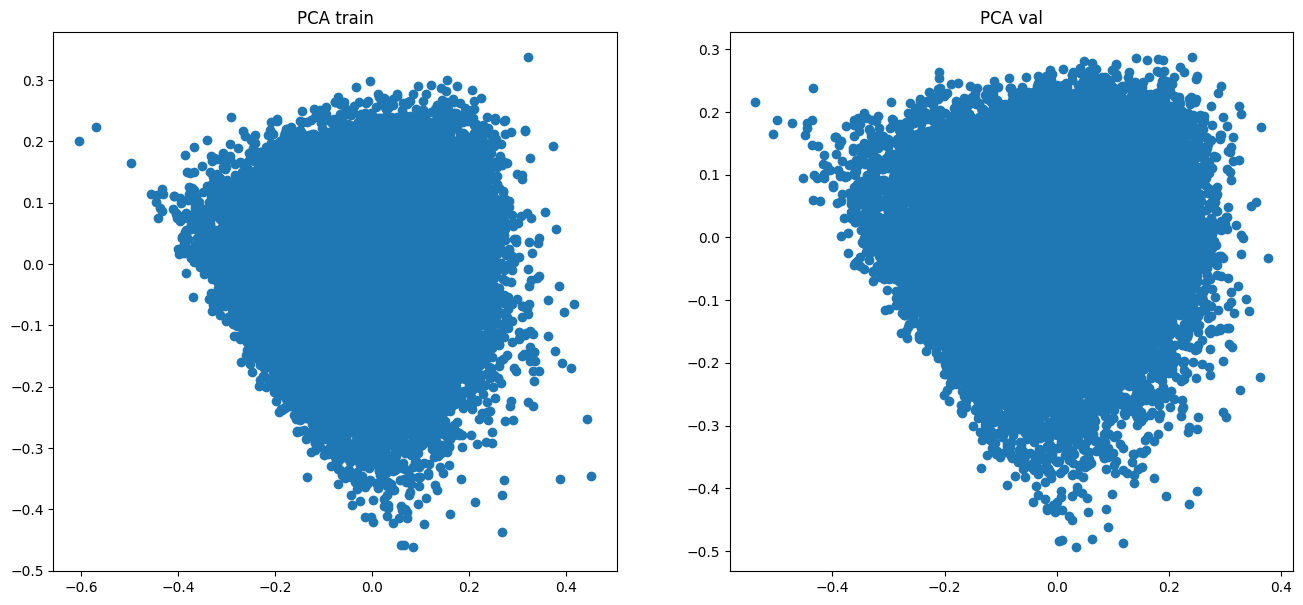

In [150]:
# PCA and r2
pca_z_train = PCA(n_components=2).fit_transform(zs_train)
pca_z_val = PCA(n_components=2).fit_transform(zs_val)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].scatter(pca_z_train[:, 0], pca_z_train[:, 1])
axes[0].set_title('PCA train')
axes[1].scatter(pca_z_val[:, 0], pca_z_val[:, 1])
axes[1].set_title('PCA val')
plt.show()

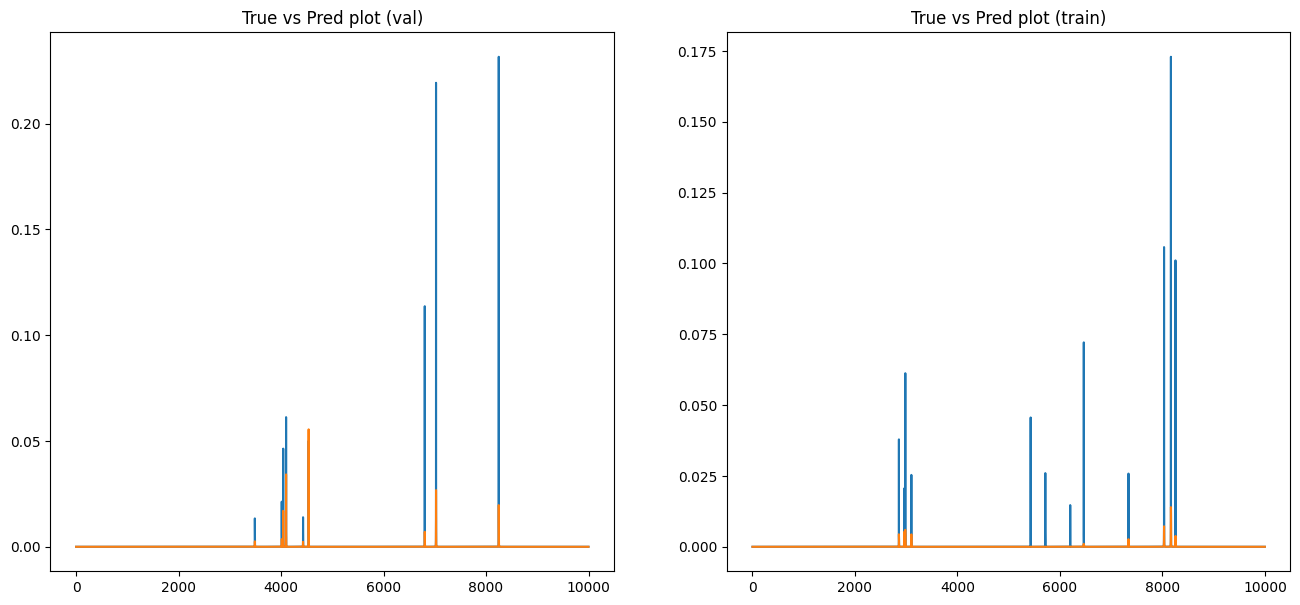

In [162]:
# reconstruction visualization
idx_val = np.random.randint(len(targets_val))
idx_train = np.random.randint(len(targets_train))

x_val = inverse_transform_data(targets_val[idx_val])
x_pred_val = inverse_transform_data(preds_val[idx_val])
x_train = inverse_transform_data(targets_train[idx_train])
x_pred_train = inverse_transform_data(preds_train[idx_train])
# x_val = targets_val[idx_val]
# x_pred_val = preds_val[idx_val]
# x_train = targets_train[idx_train]
# x_pred_train = preds_train[idx_train]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].plot(x_val, label='True')
axes[0].plot(x_pred_val, label="Pred")
axes[0].set_title('True vs Pred plot (val)')
axes[1].plot(x_train, label='True')
axes[1].plot(x_pred_train, label="Pred")
axes[1].set_title('True vs Pred plot (train)')
plt.show()

In [146]:
torch.save(model.state_dict(), '/home/andrze06/projects/Spectras-latent-space/trained_models/SimpleMLP-l256')